## Reproduce Binary Classification Train Data

-  Prepare Files that contain the data that should be included in the later train dataset
    - In this case Hemolytik_scraped.csv and DBAASP_from_CalcAMP.csv
        - Hemolytik_scraped.csv is already parsed in my case
        - DBAASP_from_CalcAMP.csv needs further preprocessing

In [5]:
from src.data_preprocessing.binary.prepare_whitelab_data import download_and_prepare_whitelab_data

Package used for Preprocessing AMP data from most common AMP Databases.

prepare_train_file should be able to process most of those databases if custom or different data is needed,

 but it could be possible that you need to adjust the logic to your use-case. The other files are specific to this project


In [6]:
download_and_prepare_whitelab_data(create_whitelab_csv=True, verbose=False)

d:\miniconda3\envs\regressor\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
from src.data_preprocessing.binary.prepare_DBAASP import create_dbaasp_hemo_file

In [8]:
dbaasb_file = "data/data_from_database/DBAASP_from_CalcAMP.csv"
save_file_to = "data/data_from_database/dbaasp_scraped.csv"

In [9]:
create_dbaasp_hemo_file(in_path=dbaasb_file,
                        out_path=save_file_to)

- When all files are in the correct format, prepare the complete train file
    - File Paths for parse_and_label_hemolytic_data are hardcoded since this function only works for our files
    - You can change the function get_filtered_and_combined_dataframe() in prepareTrainFile to add more DataBases, but those need format like the ones we use

In [10]:
from src.data_preprocessing.binary.prepare_binary_train_file import parse_and_label_hemolytic_data

hemolytik_db = 'data/data_from_database/Hemolytik_scraped.csv'
dbaasp_db = 'data/data_from_database/dbaasp_scraped.csv'

### Labeling of our data

- Internally we use a function that labels the data with 1 for positive and 0 for negative. This is by calculation the ratio of the hemolytic percentage and the concentration of the peptide to achieve this percentage.  
- Adjust the label Threshold to your needs. In our case we use 0.8 as a threshold. This means that all peptides where the relation from hemolytic percentage and concentration is greater than 0.8 are labeled as positive.

In [11]:
parse_and_label_hemolytic_data(hemolytik_db, dbaasp_db,
                               out_path='data/',
                               vote_label=False,
                               label_threshold=0.8)

Processing units
VOR Umrechnung der Einheiten
       count     min      max        mean         std    median    units
unit                                                                    
µM      4246  0.3000  25000.0  169.109480  811.000756   90.5000     [µM]
µg/ml   2063  0.2000  13800.0  235.315793  543.866154  116.7000  [µg/ml]
μM       671  0.4000    600.0   74.497996   94.680673   48.0000     [μM]
μg/ml    382  1.0000   1000.0  111.833403  120.575222   80.0000  [μg/ml]
mg/ml     38  0.0625    256.0   41.604474   87.914727    0.6100  [mg/ml]
mM        16  0.7700     50.0   19.275188   22.824952    1.5065     [mM]
NACH Umrechnung der Einheiten
      count       min            max        mean          std  median units
unit                                                                       
µM     7416  0.090389  186225.748497  296.402778  3948.714742    64.0  [µM]

UNITS before: 6 -> after: 1

Skipping filtering of ambiguous sequences.


## Train Data Inspection for binary Classification train dataset

- So far useable for Binary Classificaation Data. Are there ways to describe mlm Dataset?
- Now that we created our Train Data File we can compare them to other Train Data used by other work groups
    - In our Case we compare our Data to Whitelabs Data from PeptideBERT
        - Be careful of TODO!

In [12]:
from src.data_analysis.train_data_viewer import get_overall_stats


Package for analysis the embeddings/cls token of the peptide sequences from the fine-tuned model.
!!!STILL IN WORK AND NOT FULLY TESTED!!!



In [13]:
our_negative_path = 'data/data_for_data_viewer/our_negative.csv'
our_positive_path = 'data/data_for_data_viewer/our_positive.csv'
whitelab_negative_path = 'data/data_for_data_viewer/whitelab_data_negative_formatted.csv'
whitelab_positive_path = 'data/data_for_data_viewer/whitelab_data_positive_formatted.csv'
plot_path = 'plots/'
out_path = 'data/sequence_analysis/'

|                                             |   Our Data |   Whitelab Data |
|:--------------------------------------------|-----------:|----------------:|
| Sum Data Points                             |  7416      |       9316      |
| Positive Data [%]                           |    25.3101 |         19.6007 |
| Negative Data [%]                           |    74.6899 |         80.3993 |
| Unique Sequences                            |  4709      |       6541      |
| Unique Positives                            |  1133      |       1311      |
| Individual Positive data points             |  1877      |       1826      |
| Unique Negatives                            |  3576      |       5230      |
| Individual Negative data points             |  5539      |       7490      |
| Ambiguous unique sequences                  |   292      |        465      |
| Individual data points in both datasets     |  1450      |       1892      |
| Percent of data points in both datasets [%] |    1

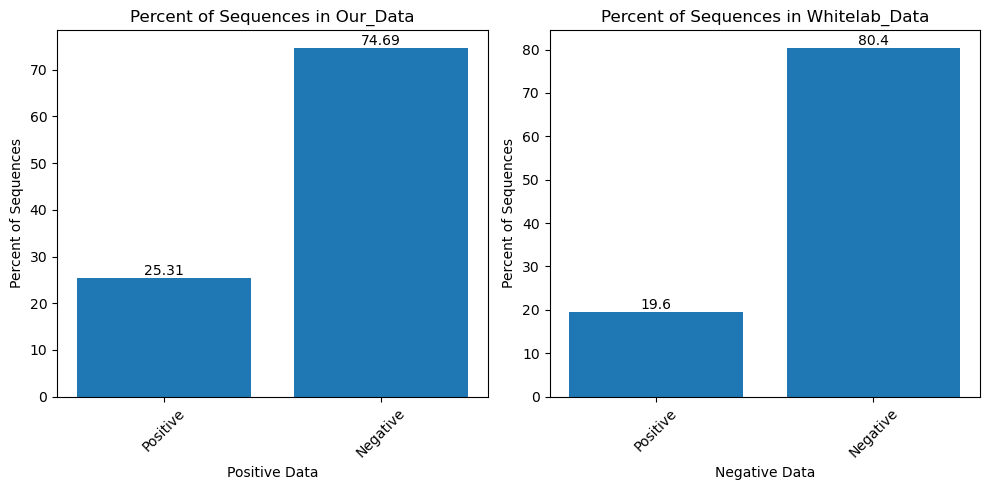

|                              |   Positive_Data |
|:-----------------------------|----------------:|
| Seqs in our data             |         1133    |
| Seqs in whitelab data        |         1311    |
| Common seqs                  |          735    |
| Common seqs % (our)          |           64.87 |
| Common seqs % (whitelab)     |           56.06 |
| Seqs in our not in whitelab  |          398    |
| Seqs % (our not in whitelab) |           35.13 |
| Seqs in whitelab not in our  |          576    |
| Seqs % (whitelab not in our) |           43.94 |

|                              |   Negative_Data |
|:-----------------------------|----------------:|
| Seqs in our data             |         3576    |
| Seqs in whitelab data        |         5230    |
| Common seqs                  |         3119    |
| Common seqs % (our)          |           87.22 |
| Common seqs % (whitelab)     |           59.64 |
| Seqs in our not in whitelab  |          457    |
| Seqs % (our not in whitelab)

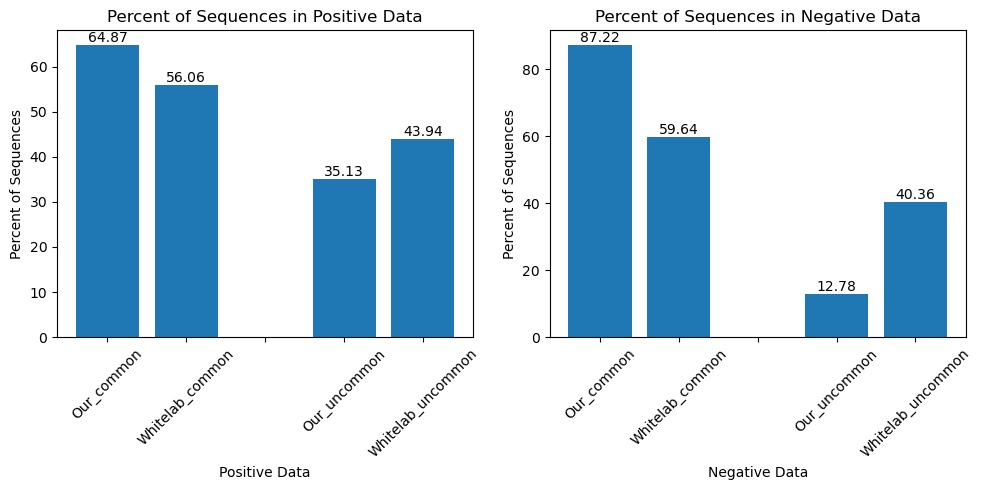

In [14]:
get_overall_stats(our_negative_path=our_negative_path,
                  our_positive_path=our_positive_path,
                  negative_to_compare_path=whitelab_negative_path,
                  positive_to_compare_path=whitelab_positive_path,
                  plot_path=plot_path,
                  out_path=out_path)